## Problem 2: Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

***

In [77]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm

In [78]:
# Generate 100,000 samples of 10 coin flips each
flips = []
for i in range(100000):
    # Each iteration generates 10 coin flips (1=heads, 0=tails)
    ten_flips = np.random.binomial(1, 0.5, 10)
    flips.append(ten_flips)
print(f"Example first sample: {flips[0]}")
print(f"Generated {len(flips)} samples of 10 coin flips each")

Example first sample: [1 1 0 0 0 0 1 1 1 0]
Generated 100000 samples of 10 coin flips each


In [79]:
# Convert to numpy array for easier manipulation
flips_array = np.array(flips)

# Count total heads and tails across all flips
#total_heads = np.sum(flips_array)
#total_tails = flips_array.size - total_heads

#or
unique, counts = np.unique(flips_array, return_counts=True)
count_dict = dict(zip(unique, counts))
total_heads = count_dict.get(1, 0)
total_tails = count_dict.get(0, 0)

heads_per_sample = np.sum(flips_array, axis=1)

# Count heads per sample (this might be more useful)
heads_per_sample = np.sum(flips_array, axis=1)
print(f"Total heads: {total_heads}")

print(f"Total tails: {total_tails}")
print(f"Total flips: {total_heads + total_tails}")

Total heads: 499334
Total tails: 500666
Total flips: 1000000


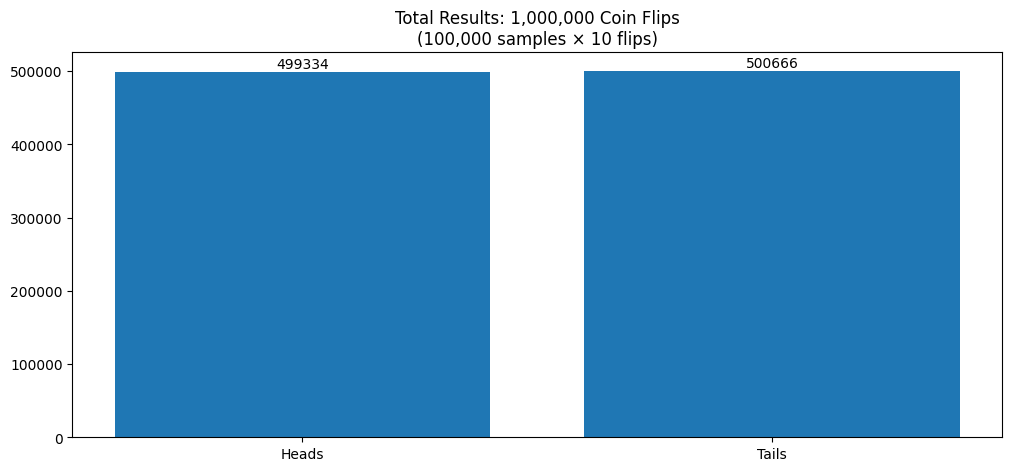

In [80]:
# Plot total heads vs tails
fig, ax1 = plt.subplots(1, figsize=(12, 5))

# Total heads vs tails
ax1.bar(['Heads', 'Tails'], [total_heads, total_tails])
ax1.bar_label(ax1.containers[0])

ax1.set_title('Total Results: 1,000,000 Coin Flips\n(100,000 samples × 10 flips)')
plt.show()

***

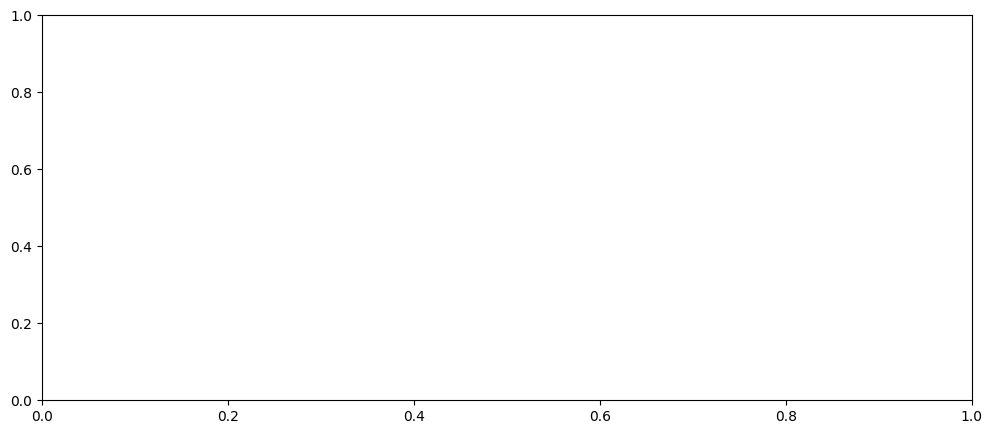

: 

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

***

## Analysis and Explanation

### Differences Observed:

1. **Sample SD (ddof=1) vs Population SD (ddof=0)**:
   - Sample SD values are consistently **higher** than Population SD values
   - This is because ddof=1 uses (n-1) in the denominator, making the result larger
   - The sample SD corrects for bias when estimating population variance from a sample

2. **Distribution Characteristics**:
   - Both distributions have similar shapes but different centers
   - Sample SD distribution is shifted to the right compared to Population SD
   - The ratio between them is approximately √(10/9) ≈ 1.054

3. **Bias Correction**:
   - Population SD (ddof=0) gives a **biased estimate** of the true population standard deviation
   - Sample SD (ddof=1) gives an **unbiased estimate** of the population standard deviation
   - This is why we typically use ddof=1 for sample statistics

### Expected Changes with Larger Sample Sizes:

1. **Convergence**: As sample size increases, the difference between ddof=0 and ddof=1 becomes smaller
2. **Reduced Bias**: The bias in ddof=0 decreases as n increases (bias factor = √((n-1)/n) → 1)
3. **Lower Variance**: Both estimators become more precise (less variability) with larger samples
4. **Practical Impact**: For very large samples (n>100), the choice between ddof=0 and ddof=1 becomes negligible

**Key Takeaway**: Always use ddof=1 for sample statistics unless you specifically need the population formula!